In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector
import warnings

In [4]:
connection = mysql.connector.connect(
user='root',
password='123456',
host='localhost',
database='big_mart'
)

In [6]:
# Create a cursor object to execute SQL queries
cursor = connection.cursor()

In [10]:
cursor.execute('SELECT * FROM big_mart_sales')
# After fetching data from the database, we are storing it into a Pandas DataFrame
big_mart_sales_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])

In [14]:
#printing first 5 records from each table
print(big_mart_sales_data)

     Item_Identifier Item_Fat_Content              Item_Type  Item_MRP  \
0                 FD               LF                  Dairy  249.8092   
1                 DR          Regular            Soft Drinks   48.2692   
2                 FD               LF                   Meat  141.6180   
3                 FD          Regular  Fruits and Vegetables  182.0950   
4                 NC               LF              Household   53.8614   
...              ...              ...                    ...       ...   
8518              FD               LF            Snack Foods  214.5218   
8519              FD          Regular           Baking Goods  108.1570   
8520              NC               LF     Health and Hygiene   85.1224   
8521              FD          Regular            Snack Foods  103.1332   
8522              DR               LF            Soft Drinks   75.4670   

     Outlet_Identifier  Outlet_Establishment_Year Outlet_Size  \
0               OUT049                       1

In [18]:
big_mart_sales_data.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate
0,FD,LF,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,9.30,0.016047
1,DR,Regular,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,5.92,0.019278
2,FD,LF,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,17.50,0.016760
3,FD,Regular,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,19.20,0.015755
4,NC,LF,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,8.93,0.014751


In [20]:
big_mart_sales_data.describe()

,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Weight_interploate,Item_Visibility_interpolate
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,140.992782,1997.831867,2181.288914,12.831222,0.070340
std,62.275067,8.371760,1706.499616,4.445074,0.049493
min,31.290000,1985.000000,33.290000,4.555000,0.003575
25%,93.826500,1987.000000,834.247400,9.000000,0.032405
50%,143.012800,1999.000000,1794.331000,12.600000,0.058182
75%,185.643700,2004.000000,3101.296400,16.600000,0.097094
max,266.888400,2009.000000,13086.964800,21.350000,0.328391


In [22]:
big_mart_sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Item_Identifier              8523 non-null   object 
 1   Item_Fat_Content             8523 non-null   object 
 2   Item_Type                    8523 non-null   object 
 3   Item_MRP                     8523 non-null   float64
 4   Outlet_Identifier            8523 non-null   object 
 5   Outlet_Establishment_Year    8523 non-null   int64  
 6   Outlet_Size                  8523 non-null   object 
 7   Outlet_Location_Type         8523 non-null   object 
 8   Outlet_Type                  8523 non-null   object 
 9   Item_Outlet_Sales            8523 non-null   float64
 10  Item_Weight_interploate      8523 non-null   float64
 11  Item_Visibility_interpolate  8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [24]:
big_mart_sales_data.isnull().sum()

Item_Identifier                0
Item_Fat_Content               0
Item_Type                      0
Item_MRP                       0
Outlet_Identifier              0
Outlet_Establishment_Year      0
Outlet_Size                    0
Outlet_Location_Type           0
Outlet_Type                    0
Item_Outlet_Sales              0
Item_Weight_interploate        0
Item_Visibility_interpolate    0
dtype: int64

data visualization

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


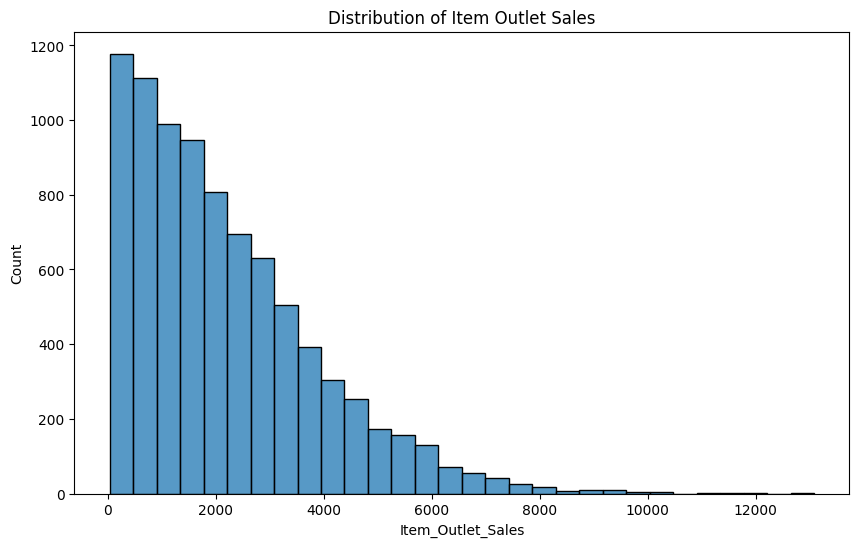

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(big_mart_sales_data['Item_Outlet_Sales'], bins=30)
plt.title('Distribution of Item Outlet Sales')
plt.show()

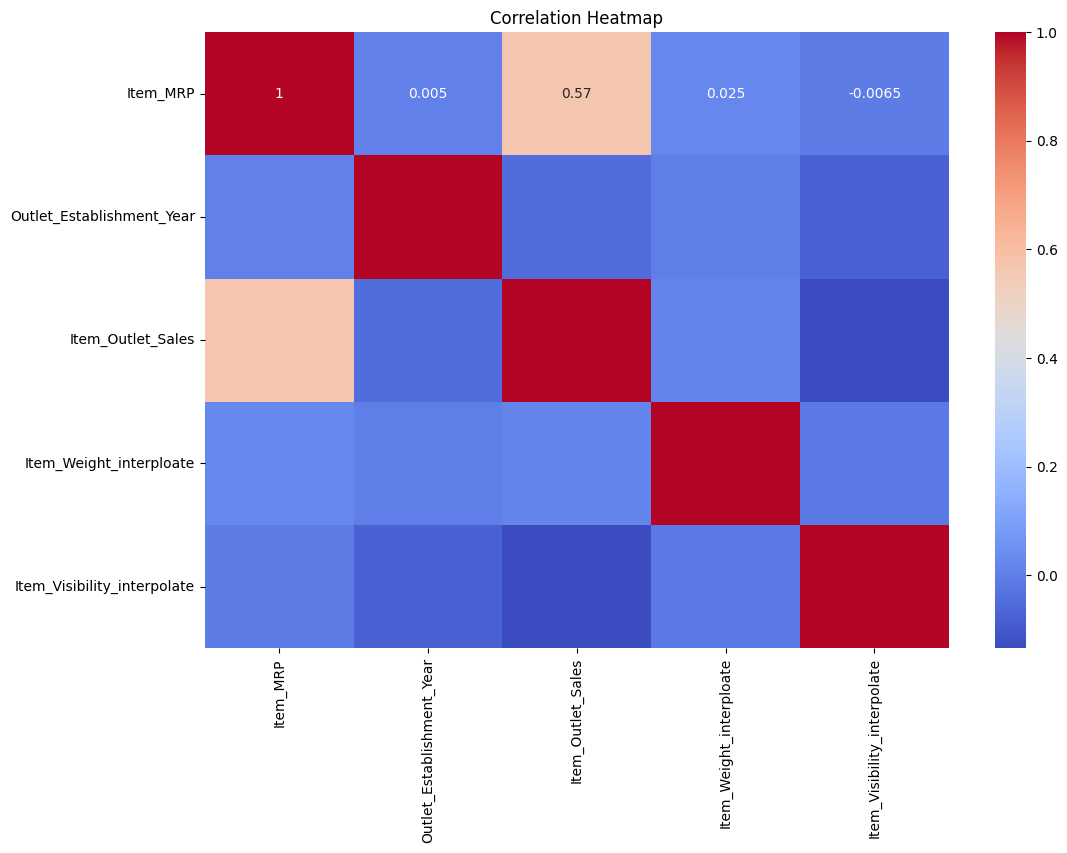

In [31]:
# Select only numeric columns
numeric_data = big_mart_sales_data.select_dtypes(include=[np.number])

# Now create the correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


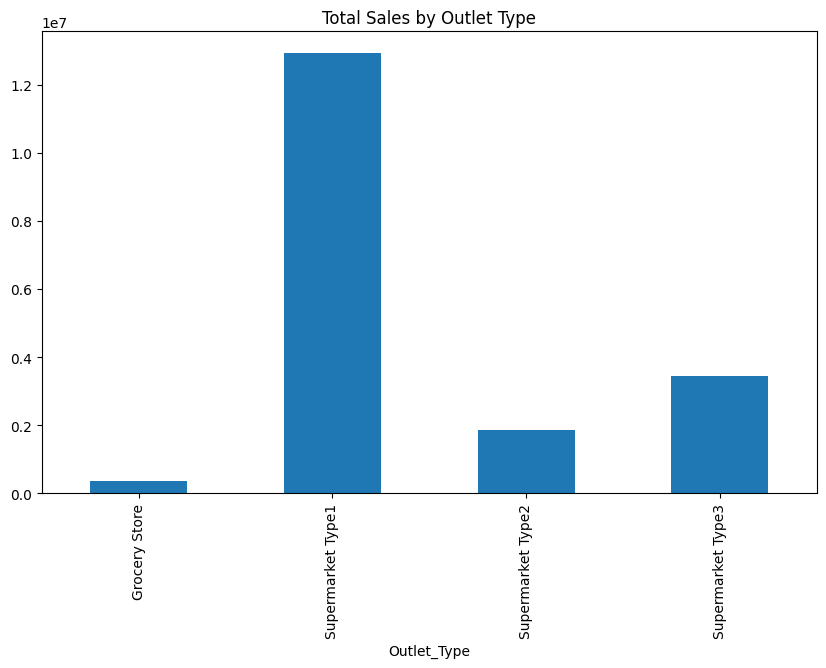

In [33]:
outlet_sales = big_mart_sales_data.groupby('Outlet_Type')['Item_Outlet_Sales'].sum()
outlet_sales.plot(kind='bar', title='Total Sales by Outlet Type', figsize=(10,6))
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


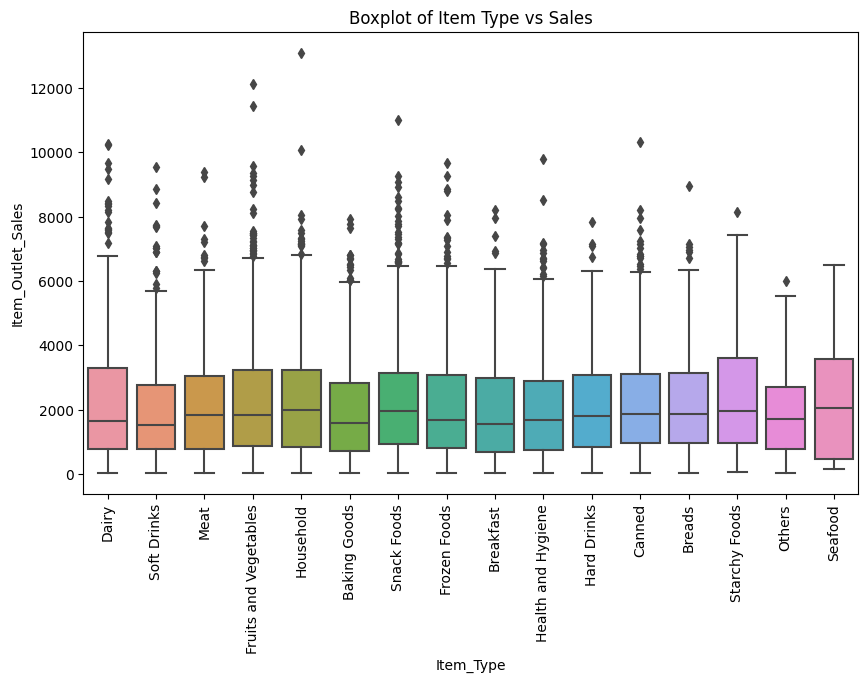

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=big_mart_sales_data)
plt.title('Boxplot of Item Type vs Sales')
plt.xticks(rotation=90)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


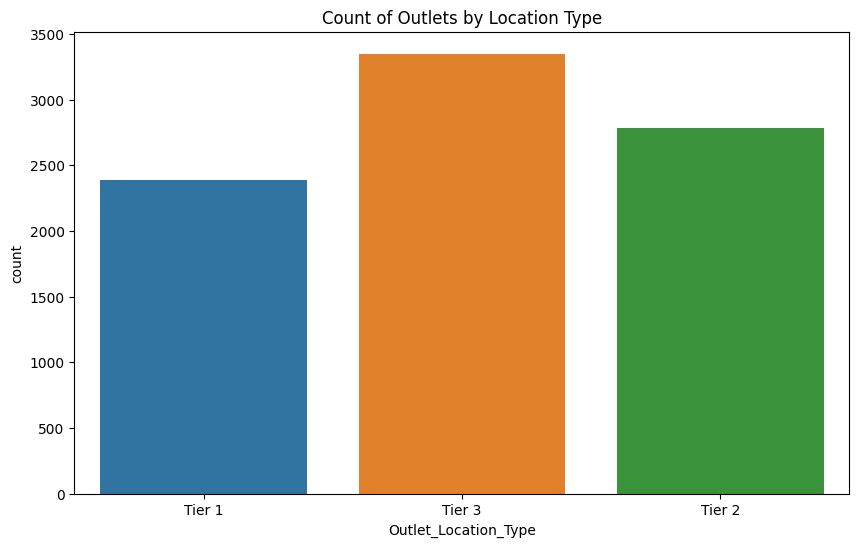

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(data=big_mart_sales_data, x='Outlet_Location_Type')
plt.title('Count of Outlets by Location Type')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


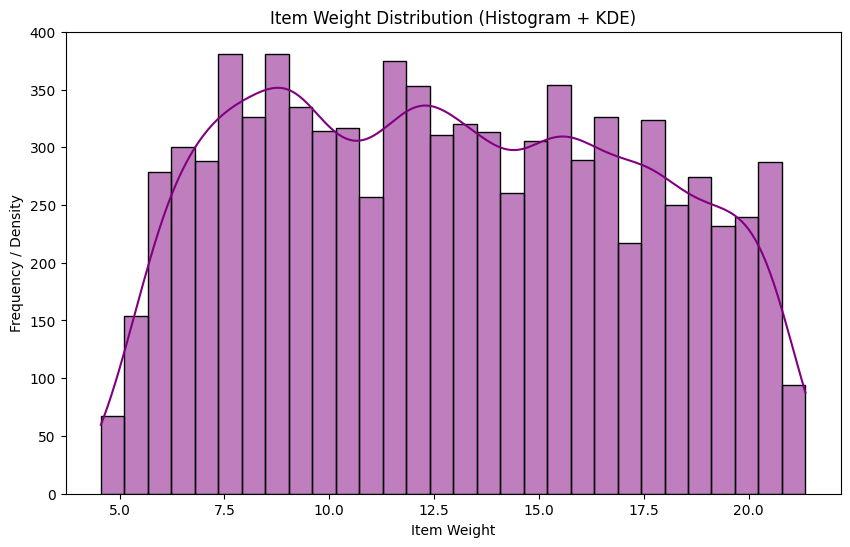

In [53]:
plt.figure(figsize=(10,6))
sns.histplot(data=big_mart_sales_data, x='Item_Weight_interploate', bins=30, kde=True, color='purple')
plt.title('Item Weight Distribution (Histogram + KDE)')
plt.xlabel('Item Weight')
plt.ylabel('Frequency / Density')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


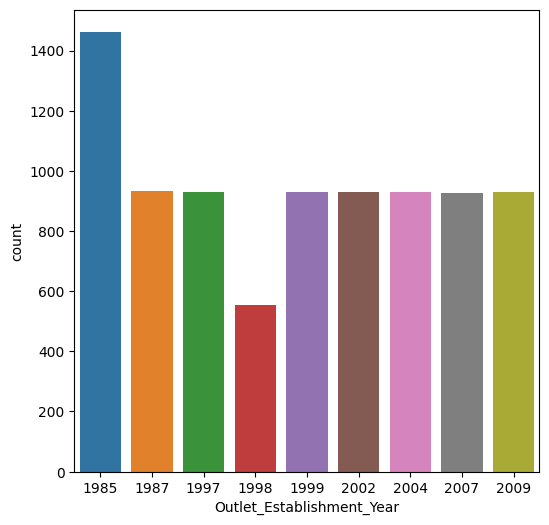

In [57]:
# Outlet_Establishment_Year column
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=big_mart_sales_data)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


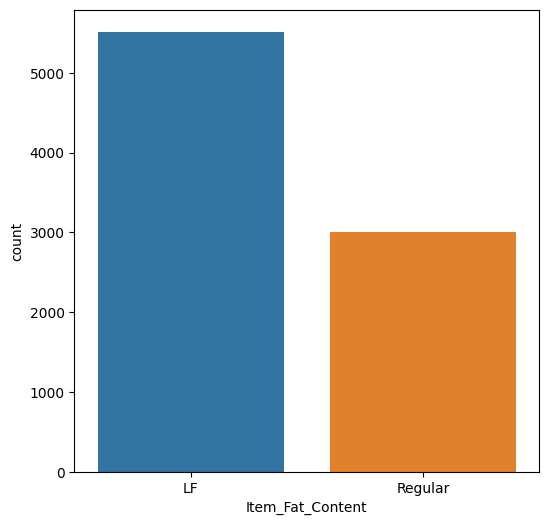

In [59]:
# Item_Fat_Content column
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=big_mart_sales_data)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


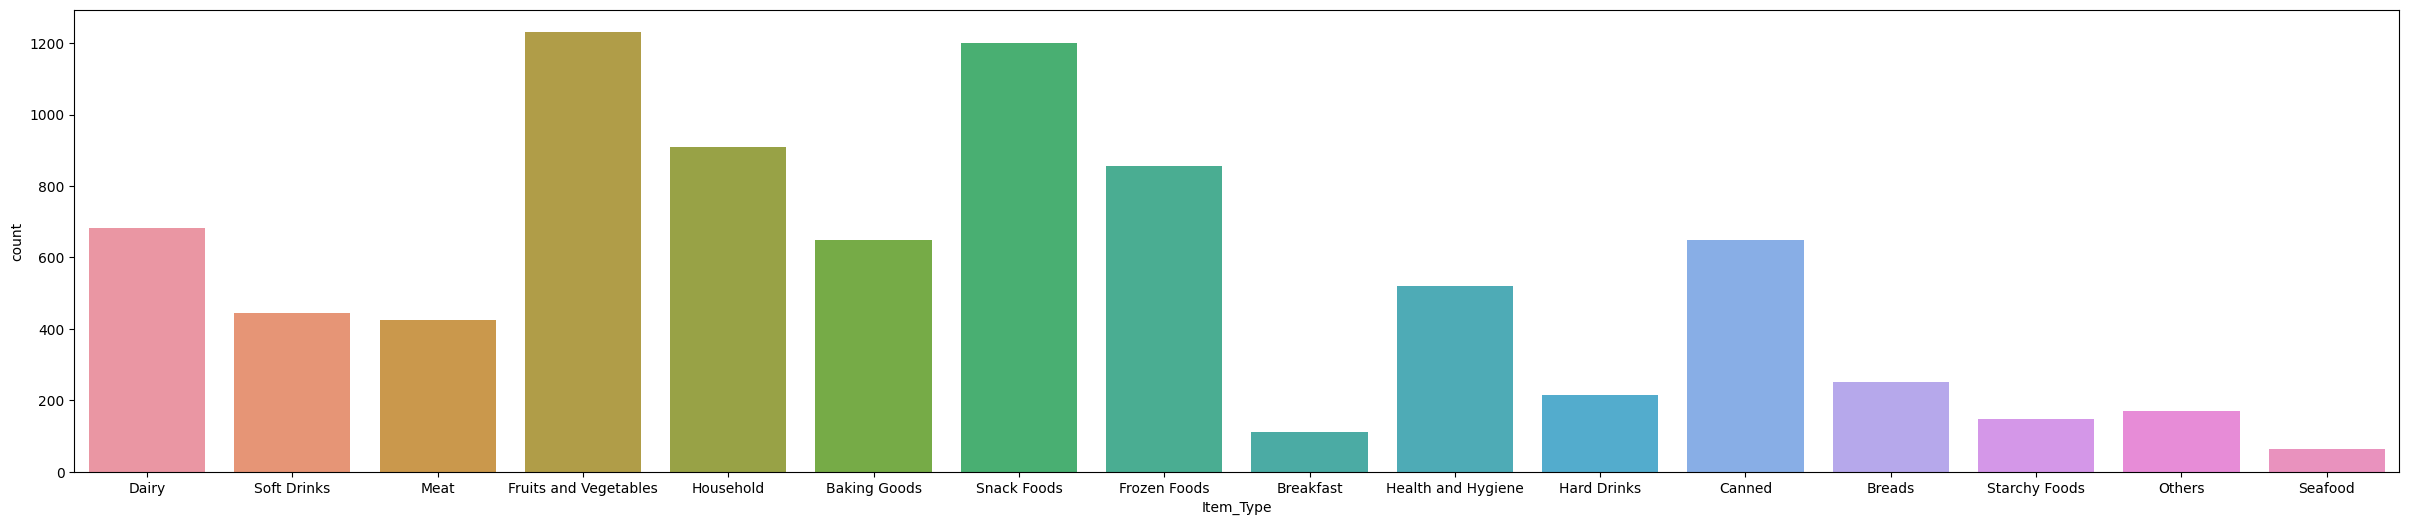

In [61]:
# Item_Type column
plt.figure(figsize=(30,6))
sns.countplot(x='Item_Type', data=big_mart_sales_data)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


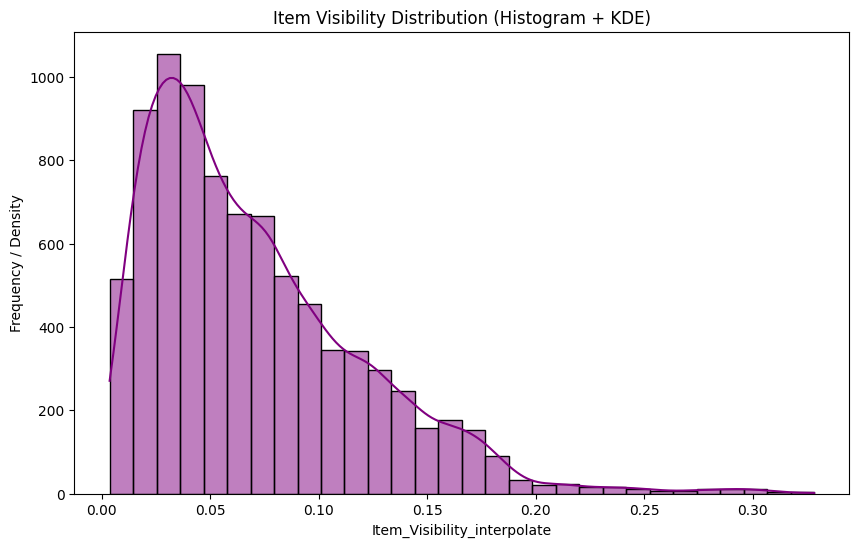

In [65]:
plt.figure(figsize=(10,6))
sns.histplot(data=big_mart_sales_data, x='Item_Visibility_interpolate', bins=30, kde=True, color='purple')
plt.title('Item Visibility Distribution (Histogram + KDE)')
plt.xlabel('Item_Visibility_interpolate')
plt.ylabel('Frequency / Density')
plt.show()